In [63]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [64]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [65]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

df = df[['sepal_length','petal_length','species']]
df.head()

,sepal_length,petal_length,species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0


In [66]:
X = df.drop(columns='species')
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg = LogisticRegression(multi_class='multinomial')     # as you write multi_class='multinomial, the model would automatically realize that you want to performn 'SoftMax Regression'
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)


print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred))



1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


,0,1,2
0,10,0,0
1,0,9,0
2,0,0,11


In [ ]:
# predicting the probability

query = np.array([[3.4,2.7]])
reg.predict_proba(query)        # will print the probability of every class

array([[8.09242380e-01, 1.90157191e-01, 6.00428887e-04]])

In [68]:
reg.predict(query)

array([0])

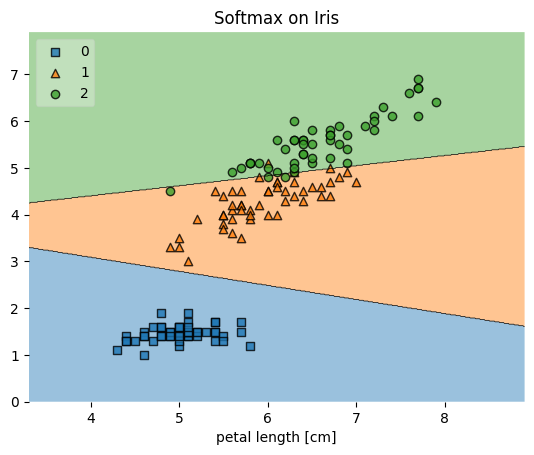

In [69]:
# Plotting the Graph

from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X.values, y.values, reg, legend=2)

plt.xlabel('sepal length [cm]')
plt.xlabel('petal length [cm]')
plt.title('Softmax on Iris')

plt.show()